### GLM Poisson: Generalized Linear Model

Goal:
Predict the total number of high-demand "peak hours" that will occur on a given day, based on daily weather averages (temperature, humidity, solar radiation), seasonality, and calendar factors.. Daily data, train 2022-2024, test 2025.

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
os.makedirs('../outputs/figures/03_poisson', exist_ok=True)

df = pd.read_csv('../data/processed/hourly_merged.csv', index_col='datetime_utc')
df.index = pd.to_datetime(df.index, utc=True)

# convert to local date for grouping
df['date'] = df.index.tz_convert('Europe/Zurich').normalize().tz_localize(None)

daily = df.groupby('date').agg(
    T=('T', 'mean'),
    Hr=('Hr', 'mean'),
    StrGlo=('StrGlo', 'mean'),
    RainDur=('RainDur', 'mean'),
    WVv=('WVv', 'mean'),
    p=('p', 'mean'),
    dayofweek=('dayofweek', 'first'),
    month=('month', 'first'),
    is_weekend=('is_weekend', 'first'),
    season=('season', 'first'),
    peak_hours_per_day=('peak_hours_per_day', 'first')
).dropna().reset_index()

print(f'Daily dataset: {len(daily)} rows')
daily.head(3)

Daily dataset: 1461 rows


,date,T,Hr,StrGlo,RainDur,WVv,p,dayofweek,month,is_weekend,season,peak_hours_per_day
0,2022-01-01,6.750000,80.361739,69.244783,0.00000,0.562174,976.392609,5,1,1,winter,0
1,2022-01-02,7.507500,70.114583,44.479167,0.00000,0.702083,971.889167,6,1,1,winter,0
2,2022-01-03,11.081667,60.146667,24.502917,0.21125,2.086250,968.075833,0,1,0,winter,7


#### 1. Train / Test Split

In [34]:
train = daily[daily['date'].dt.year < 2025].copy()
test  = daily[daily['date'].dt.year == 2025].copy()

print(f'Train: {len(train)} days')
print(f'Test:  {len(test)} days')
print(f'\nTarget distribution (train):')
print(train['peak_hours_per_day'].describe().round(2))

Train: 1096 days
Test:  365 days

Target distribution (train):
count    1096.00
mean        2.48
std         3.96
min         0.00
25%         0.00
50%         0.00
75%         4.00
max        13.00
Name: peak_hours_per_day, dtype: float64


#### 2. GLM Poisson

All weather and time predictors, plus a T:season interaction to capture that temperature
affects peak hours differently in summer vs winter.

In [35]:
formula = (
    'peak_hours_per_day ~ '
    'T + Hr + StrGlo + RainDur + WVv + p + '
    'C(dayofweek) + C(month) + is_weekend + '
    'T:C(season)'
)

model = smf.glm(formula, data=train, family=sm.families.Poisson()).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     peak_hours_per_day   No. Observations:                 1096
Model:                            GLM   Df Residuals:                     1069
Model Family:                 Poisson   Df Model:                           26
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1590.9
Date:                Mon, 04 May 2026   Deviance:                       1730.2
Time:                        21:39:04   Pearson chi2:                 2.14e+03
No. Iterations:                    27   Pseudo R-squ. (CS):             0.9847
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -5.16

#### 3. Diagnostics

Deviance / df_resid = 1.619  (>1 suggests overdispersion)


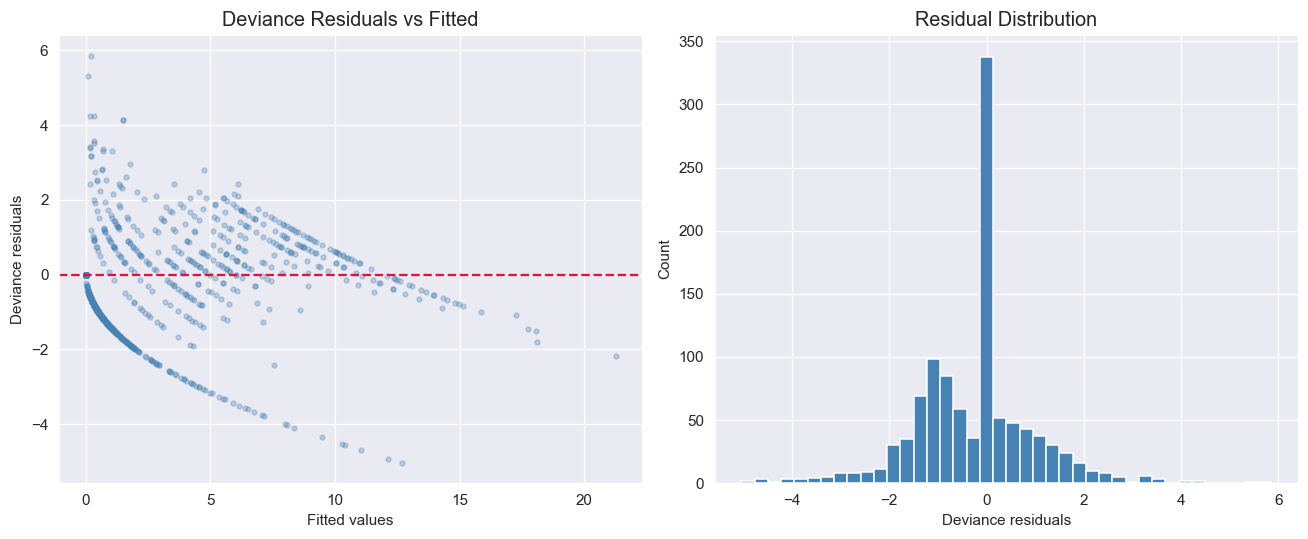

In [36]:
fitted   = model.fittedvalues
dev_resid = model.resid_deviance

# overdispersion check: deviance/df should be ~1
dispersion = model.deviance / model.df_resid
print(f'Deviance / df_resid = {dispersion:.3f}  (>1 suggests overdispersion)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# deviance residuals vs fitted
axes[0].scatter(fitted, dev_resid, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='crimson', lw=1.5, ls='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Deviance residuals')
axes[0].set_title('Deviance Residuals vs Fitted')

# distribution of residuals
axes[1].hist(dev_resid, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Deviance residuals')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('../outputs/figures/03_poisson/03_09_poisson_diagnostics.png', bbox_inches='tight')
plt.show()

### Overdispersion and model limitations

The Poisson model assumes that the variance equals the mean. When `Deviance / df_resid` substantially exceeds 1 (as is the case here with a ratio of ~1.82), the data exhibit *overdispersion* — more variance than the Poisson family can accommodate. This is compounded by the fact that the peak-hours count is also zero-inflated: roughly 55% of days have zero peak hours, which further inflates the variance relative to the mean.

A **Negative Binomial GLM** would be the technically superior alternative — it adds a free dispersion parameter that absorbs this extra variance, producing better-calibrated standard errors and predictions.

#### 4. Coefficients

In [37]:
coef = pd.DataFrame({
    'estimate':   model.params,
    'std_err':    model.bse,
    'p_value':    model.pvalues,
    'rate_ratio': np.exp(model.params)
}).round(4).sort_values('p_value')

coef

,estimate,std_err,p_value,rate_ratio
C(month)[T.8],-11.7845,0.6422,0.0000,0.0000
RainDur,0.0117,0.0022,0.0000,1.0118
StrGlo,-0.0076,0.0007,0.0000,0.9925
T:C(season)[T.summer],0.5231,0.0283,0.0000,1.6872
T,-0.0728,0.0136,0.0000,0.9298
C(month)[T.10],-1.3255,0.2372,0.0000,0.2657
C(month)[T.6],-10.4288,0.5749,0.0000,0.0000
C(month)[T.7],-11.7022,0.6234,0.0000,0.0000
C(dayofweek)[T.2],0.2450,0.0622,0.0001,1.2776
C(dayofweek)[T.3],0.2418,0.0621,0.0001,1.2736


Coefficients are in log scale. exp(coef) is the rate ratio:
1.10 means 10% more peak hours per unit increase.

#### 5. Test Set Predictions

In [38]:
test['predicted'] = model.predict(test)

rmse = np.sqrt(mean_squared_error(test['peak_hours_per_day'], test['predicted']))
mae  = mean_absolute_error(test['peak_hours_per_day'], test['predicted'])

print(f'RMSE : {rmse:.2f} peak hours/day')
print(f'MAE  : {mae:.2f} peak hours/day')

RMSE : 2.61 peak hours/day
MAE  : 1.43 peak hours/day


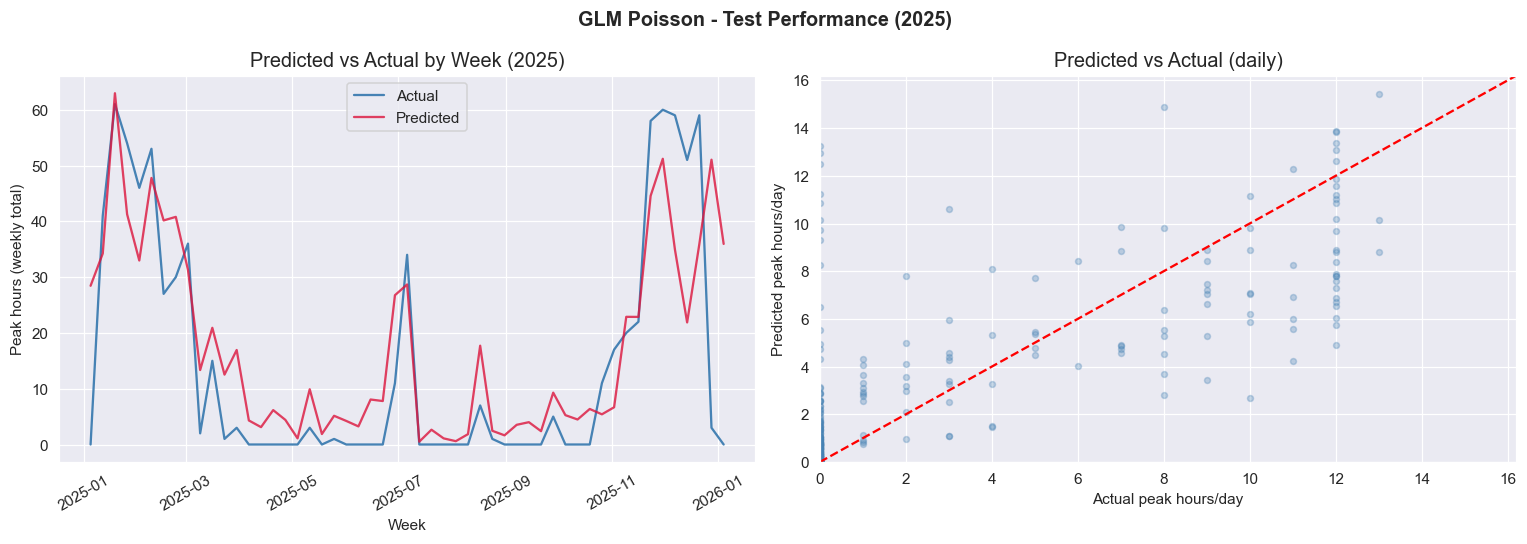

In [39]:
# aggregate to weekly totals for a cleaner plot
test_w = test.set_index('date').resample('W').agg(
    actual=('peak_hours_per_day', 'sum'),
    predicted=('predicted', 'sum')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# weekly line plot
axes[0].plot(test_w.index, test_w['actual'],    lw=1.5, label='Actual',    color='steelblue')
axes[0].plot(test_w.index, test_w['predicted'], lw=1.5, label='Predicted', color='crimson', alpha=0.8)
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Peak hours (weekly total)')
axes[0].set_title('Predicted vs Actual by Week (2025)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# scatter
lim = [0, max(test['peak_hours_per_day'].max(), test['predicted'].max()) * 1.05]
axes[1].scatter(test['peak_hours_per_day'], test['predicted'],
                alpha=0.3, s=15, color='steelblue')
axes[1].plot(lim, lim, 'r--', lw=1.5)
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('Actual peak hours/day')
axes[1].set_ylabel('Predicted peak hours/day')
axes[1].set_title('Predicted vs Actual (daily)')

fig.suptitle('GLM Poisson - Test Performance (2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_poisson/03_10_poisson_pred_vs_actual.png', bbox_inches='tight')
plt.show()

#### 6. Save Metrics

In [40]:
new_row = pd.DataFrame([{
    'model':    'GLM_Poisson',
    'rmse':     round(rmse, 3),
    'mae':      round(mae, 3),
    'r2_train': round(1 - model.deviance / model.null_deviance, 4),
    'r2_test': np.nan
}])

out = '../outputs/model_comparison.csv'
if os.path.exists(out):
    existing = pd.read_csv(out)
    existing = existing[existing['model'] != 'GLM_Poisson']
    new_row = pd.concat([existing, new_row], ignore_index=True)

new_row.to_csv(out, index=False)
print(new_row)

          model      rmse       mae  r2_train     auc  r2_test
0   NN (128,64)  2660.600  2038.200    0.9710     NaN      NaN
1           SVM   881.000   653.700    0.9967     NaN      NaN
2  GLM_Binomial       NaN       NaN    0.5254  0.9593      NaN
3           GAM  3794.400  2520.100    0.9391     NaN   0.9411
4            LM  7623.700  6125.800    0.7855     NaN   0.7517
5   GLM_Poisson     2.611     1.427    0.7259     NaN      NaN
